# Figure generation notebook
Run this notebook to regenerate example figures used in the manuscript.

In [2]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt

In [3]:
project_root = pathlib.Path.cwd().parent
figures_dir = project_root / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

Scenario                    Name  Mean_Collapse  Std_Collapse  Never_Collapsed_Frac  Mean_Duty_Cycle  Std_Duty_Cycle  Mean_Cycles  Std_Cycles  Mean_Growth_Slope  Std_Growth_Slope
      S1 Big Brother is Watching        205.840    124.067540                 0.000         0.622645        0.077842        9.755    1.927427           0.000210          0.006073
      S2               Wild West        383.215    148.491814                 0.000         0.613685        0.093672        5.840    1.369087           0.001420          0.006711
      S3              Golden Age       1000.000      0.000000                 1.000         1.000000        0.000000        0.000    0.000000           0.000100          0.000000
      S4    Living with the Land        240.625     17.212913                 0.000         0.380990        0.024875        6.600    0.616441           0.006000          0.000000
      S5           Transhumanism        810.590    299.296462                 0.635         0.990650     

/var/folders/38/2zkx65c923d5y4297z_j_w0r0000gn/T/ipykernel_75273/2842207569.py:296: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


PosixPath('/Users/celia/VSCode/technocycles/figures/tech_and_resources.png')

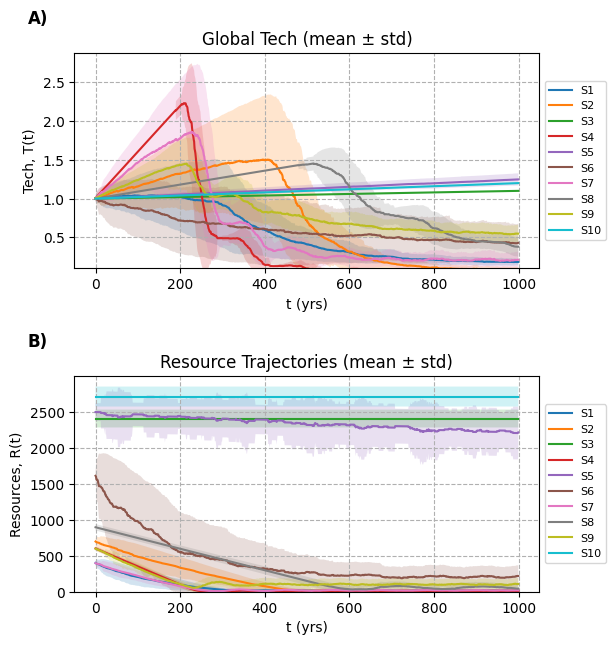

In [ ]:
# post jacob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ——— 1) Scenario definitions with per-scenario collapse/recovery params ———
# r            : per-tick linear growth (from Haqq‐Misra Table 9)
# R0_mean      : initial resource stock
# delta_mean   : per-tick resource drain
# cf_mean      : collapse depth (fraction of tech retained)
# rd_mean      : recovery delay (ticks)
# rf_mean      : recovery fraction (of R0)
# h_ex_risk    : existential‐risk hazard rate (per tick)

scenario_params = {
    "S1": {
        "Name": "Big Brother is Watching",
        "r": 0.0020,
        "R0_mean": 400,      # Scarcity-driven, centralized economy limits available resources
        "delta_mean": 1.2,   # High consumption under top-down industrial control
        "cf_mean": 0.6,      # Strong state preserves a significant portion of technology during collapse
        "rd_mean": 40,       # Centralized control allows for rapid recovery
        "rf_mean": 0.15,     # Recovery remains partial due to authoritarian inefficiencies
        "h_ex_risk": 0.003   # High existential fragility due to systemic over-dependence on central authority
    },
    "S2": {
        "Name": "Wild West",
        "r": 0.0026,
        "R0_mean": 700,      # Moderately strong resource base with uneven distribution
        "delta_mean": 1.5,   # High resource drain in a deregulated, competitive environment
        "cf_mean": 0.3,      # Weak coordination leads to major losses in collapse
        "rd_mean": 70,       # Slow, chaotic recovery following breakdowns
        "rf_mean": 0.10,     # Minimal recovery, reflecting uncoordinated social systems
        "h_ex_risk": 0.001   # Moderate risk from instability and societal fragmentation
    },
    "S3": {
        "Name": "Golden Age",
        "r": 0.0001,
        "R0_mean": 2400,     # Post-scarcity society with abundant shared resources
        "delta_mean": 0.0,   # Circular economy eliminates extractive drain
        "cf_mean": 1.0,      # No collapses; high resilience due to robust institutions
        "rd_mean": 0,
        "rf_mean": 1.0,
        "h_ex_risk": 0.0     # No existential risk under stable, egalitarian conditions
    },
    "S4": {
        "Name": "Living with the Land",
        "r": 0.0060,
        "R0_mean": 600,      # Resource base constrained by low-impact subsistence practices
        "delta_mean": 2.5,   # Seasonal and cyclical living leads to fluctuating but high net drain
        "cf_mean": 0.2,      # Deep collapses reflect vulnerability to ecological perturbations
        "rd_mean": 100,      # Recovery tied to slow ecological and social cycles
        "rf_mean": 0.10,     # Limited technological rebuilding after collapse
        "h_ex_risk": 0.0     # Stable in the long run; no existential threats from tech
    },
    "S5": {
        "Name": "Transhumanism",
        "r": 0.0003,
        "R0_mean": 2500,     # High baseline from post-biological infrastructure and terraforming
        "delta_mean": 0.1,   # Extremely efficient systems with negligible waste
        "cf_mean": 0.9,      # High resilience due to biosynthetic integration
        "rd_mean": 20,       # Rapid recovery via automated systems and enhancements
        "rf_mean": 0.80,     # Strong capacity to bounce back from failure
        "h_ex_risk": 0.0005  # Slight risk remains due to high complexity and interdependence
    },
    "S6": {
        "Name": "Sword of Damocles",
        "r": 0.0018,
        "R0_mean": 1600,     # Technosphere-dependent systems maintain high initial resources
        "delta_mean": 1.,   # Moderate drain under engineered ecological management
        "cf_mean": 0.4,      # Collapses are substantial when tightly coupled systems fail
        "rd_mean": 50,
        "rf_mean": 0.25,     # Recovery is partial; high-tech dependencies slow rebuilding
        "h_ex_risk": 0.005   # High existential risk from cascading failures in precision systems
    },
    "S7": {
        "Name": "Restoration",
        "r": 0.0060,
        "R0_mean": 400,     # Decent resource base reclaimed after major collapse
        "delta_mean": 1.5,   # Modest resource use in restored, decentralized communities
        "cf_mean": 0.3,      # Initial collapse was deep, triggering a shift in civilization model
        "rd_mean": 60,       # Recovery takes time as new institutions emerge
        "rf_mean": 0.20,     # Rebuilding is limited but stable
        "h_ex_risk": 0.001   # Some risk remains but substantially mitigated
    },
    "S8": {
        "Name": "Ouroboros",
        "r": 0.0009,
        "R0_mean": 900,      # Mid-level resource pool with periodic replenishment
        "delta_mean": 1.5,   # Repeated expansion and contraction drives high drain
        "cf_mean": 0.5,      # Cyclical society experiences moderate collapses
        "rd_mean": 70,       # Rebuilding takes a while but is expected as part of the cycle
        "rf_mean": 0.20,
        "h_ex_risk": 0.0     # Predictable oscillations without catastrophic risks
    },
    "S9": {
        "Name": "Deus Ex Machina",
        "r": 0.0029,
        "R0_mean": 600,      # Intense industrial drive starts from a smaller base
        "delta_mean": 2.5,   # High extraction to fuel large-scale engineering projects
        "cf_mean": 0.6,      # Advanced systems retain some function post-collapse
        "rd_mean": 20,       # Fast tech-based recovery
        "rf_mean": 0.40,     # Substantial recovery reflects large-scale automation
        "h_ex_risk": 0.001
    },
    "S10": {
        "Name": "Out of Eden",
        "r": 0.0002,
        "R0_mean": 2700,     # Maximum planetary resource base under minimalist stewardship
        "delta_mean": 0.0,   # Minimal-to-zero impact lifestyle
        "cf_mean": 1.0,      # No collapse expected in this stable scenario
        "rd_mean": 0,
        "rf_mean": 1.0,
        "h_ex_risk": 0.0     # Fully stable; technosphere harmonized with biosphere
    }
}


# ——— Monte Carlo uncertainty fractions ———
frac_R0    = 0.05   # 5% uncertainty in initial resources — reflects variability in ecological baseline, access, or terraforming success
frac_delta = 0.05   # 5% uncertainty in resource consumption — influenced by lifestyle, governance, efficiency, and external shocks
frac_cf    = 0.05   # 5% uncertainty in collapse depth — represents structural resilience variability and response to collapse triggers
std_rd     = 10    # ±10 ticks in recovery delay — captures differences in rebuilding pace (e.g., centralized vs distributed societies)
frac_rf    = 0.05   # 5% uncertainty in recovery fraction — reflects institutional memory, automation, and community cohesion


# Simulation settings
lifespan   = 1000
replicates = 200
rng        = np.random.default_rng(12345)

# ——— 2) Single‐run simulator with existential risk ———
def simulate_run(r, R0, delta, cf, rd, rf, h, rng):
    T    = 1.0
    R    = R0
    in_c = False
    timer= 0

    tech_ts = np.empty(lifespan)
    res_ts  = np.empty(lifespan)
    collapse_events = []
    cycles  = 0

    for t in range(lifespan): 
        if in_c:
            timer += 1
            if timer >= rd:
                R     = R0 * rf
                in_c  = False
                timer = 0
        else:
            # Linear growth
            T += r
            # Resource drain
            R -= delta
            # Existential risk collapse
            if rng.random() < h:
                R = 0
            # Check collapse either way
            if R <= 0:
                R = 0
                in_c = True
                timer = 0
                T   *= cf
                collapse_events.append(t)
                cycles += 1

        tech_ts[t] = T
        res_ts[t]  = R

    first_collapse = collapse_events[0] if collapse_events else lifespan
    duty_cycle    = np.sum(res_ts > 0) / lifespan
    growth_slope  = np.mean(np.diff(tech_ts[:20]))

    return tech_ts, res_ts, first_collapse, cycles, duty_cycle, growth_slope

# ——— 3) Monte Carlo loop ———
records     = []
tech_curves = {}
res_curves  = {}

def safe_triangular(rng, center, frac, min_val=0, max_val=1):
    """
    Triangular sampling with fallback to fixed value if frac = 0 or bounds degenerate.
    """
    if frac == 0:
        return center
    left  = max(min_val, center * (1 - frac))
    right = min(max_val, center * (1 + frac))
    if np.isclose(left, right):
        return center
    return np.clip(rng.triangular(left, center, right), min_val, max_val)

for code, p in scenario_params.items():
    tech_runs, res_runs = [], []
    Ls, Cs, Ds, Ss      = [], [], [], []

    for _ in range(replicates):
        # Fixed growth rate
        r = p["r"]

        # Uniform noise
        R0    = max(1.0, rng.normal(p["R0_mean"], frac_R0 * p["R0_mean"])) if frac_R0 > 0 else p["R0_mean"]
        delta = max(0.0, rng.normal(p["delta_mean"], frac_delta * p["delta_mean"])) if frac_delta > 0 else p["delta_mean"]

        # Triangular or fixed
        cf = safe_triangular(rng, p["cf_mean"], frac_cf)
        rf = safe_triangular(rng, p["rf_mean"], frac_rf)
        rd = max(0, rng.normal(p["rd_mean"], std_rd)) if std_rd > 0 else p["rd_mean"]

        # Fixed existential hazard
        h = p["h_ex_risk"]

        tech_ts, res_ts, L, C, D, S = simulate_run(r, R0, delta, cf, rd, rf, h, rng)

        tech_runs.append(tech_ts)
        res_runs .append(res_ts)
        Ls.append(L)
        Cs.append(C)
        Ds.append(D)
        Ss.append(S)

    arr_tech = np.vstack(tech_runs)
    arr_res  = np.vstack(res_runs)
    tech_curves[code] = arr_tech
    res_curves[code]  = arr_res

    records.append({
        "Scenario":             code,
        "Name":                 p["Name"],
        "Mean_Collapse":        np.mean(Ls),
        "Std_Collapse":         np.std(Ls),
        "Never_Collapsed_Frac": np.mean([l==lifespan for l in Ls]),
        "Mean_Duty_Cycle":      np.mean(Ds),
        "Std_Duty_Cycle":       np.std(Ds),
        "Mean_Cycles":          np.mean(Cs),
        "Std_Cycles":           np.std(Cs),
        "Mean_Growth_Slope":    np.mean(Ss),
        "Std_Growth_Slope":     np.std(Ss),
    })

summary_df = pd.DataFrame(records)
print(summary_df.to_string(index=False))
summary_df.to_csv("technosphere_summary.csv", index=False)

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Create a figure with custom layout
fig = plt.figure(figsize=(6, 7))
gs = GridSpec(2, 1, figure=fig, hspace=0.5)  # Adjust spacing between rows

ticks = np.arange(lifespan)

# Plot A: Tech
ax1 = fig.add_subplot(gs[0])
for code in scenario_params:
    mu = tech_curves[code].mean(axis=0)
    sd = tech_curves[code].std(axis=0)
    ax1.plot(ticks, mu, label=code)
    ax1.fill_between(ticks, mu - sd, mu + sd, alpha=0.2)
ax1.set_ylabel("Tech, T(t)")
ax1.set_xlabel("t (yrs)")
ax1.set_ylim(0.1)
ax1.set_title("Global Tech (mean ± std)")
ax1.grid(True, ls='--')
ax1.legend(fontsize=8, loc='center left', bbox_to_anchor=(1, 0.5))
ax1.text(-0.1, 1.2, "A)", transform=ax1.transAxes, fontsize=12, fontweight='bold', va='top')

# Plot B: Resources
ax2 = fig.add_subplot(gs[1])
for code in scenario_params:
    mu = res_curves[code].mean(axis=0)
    sd = res_curves[code].std(axis=0)
    ax2.plot(ticks, mu, label=code)
    ax2.fill_between(ticks, mu - sd, mu + sd, alpha=0.2)
ax2.set_ylabel("Resources, R(t)")
ax2.set_xlabel("t (yrs)")
ax2.set_ylim(0)
ax2.set_title("Resource Trajectories (mean ± std)")
ax2.grid(True, ls='--')
ax2.legend(fontsize=8, loc='center left', bbox_to_anchor=(1, 0.5))
ax2.text(-0.1, 1.2, "B)", transform=ax2.transAxes, fontsize=12, fontweight='bold', va='top')

# Frame styling
for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(0.8)

plt.tight_layout()
output_path = figures_dir / 'tech_and_resources.png'
plt.savefig(output_path, dpi=300, bbox_inches="tight")
output_path

In [ ]:
# post jacob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ——— 1) Scenario definitions with per-scenario collapse/recovery params ———
# r            : per-tick linear growth (from Haqq‐Misra Table 9)
# R0_mean      : initial resource stock
# delta_mean   : per-tick resource drain
# cf_mean      : collapse depth (fraction of tech retained)
# rd_mean      : recovery delay (ticks)
# rf_mean      : recovery fraction (of R0)
# h_ex_risk    : existential‐risk hazard rate (per tick)

scenario_params = {
    "S1": {
        "Name": "Big Brother is Watching",
        "r": 0.0020,
        "R0_mean": 400,      # Scarcity-driven, centralized economy limits available resources
        "delta_mean": 1.2,   # High consumption under top-down industrial control
        "cf_mean": 0.6,      # Strong state preserves a significant portion of technology during collapse
        "rd_mean": 40,       # Centralized control allows for rapid recovery
        "rf_mean": 0.15,     # Recovery remains partial due to authoritarian inefficiencies
        "h_ex_risk": 0.003   # High existential fragility due to systemic over-dependence on central authority
    },
    "S2": {
        "Name": "Wild West",
        "r": 0.0026,
        "R0_mean": 700,      # Moderately strong resource base with uneven distribution
        "delta_mean": 1.5,   # High resource drain in a deregulated, competitive environment
        "cf_mean": 0.3,      # Weak coordination leads to major losses in collapse
        "rd_mean": 70,       # Slow, chaotic recovery following breakdowns
        "rf_mean": 0.10,     # Minimal recovery, reflecting uncoordinated social systems
        "h_ex_risk": 0.001   # Moderate risk from instability and societal fragmentation
    },
    "S3": {
        "Name": "Golden Age",
        "r": 0.0001,
        "R0_mean": 2400,     # Post-scarcity society with abundant shared resources
        "delta_mean": 0.0,   # Circular economy eliminates extractive drain
        "cf_mean": 1.0,      # No collapses; high resilience due to robust institutions
        "rd_mean": 0,
        "rf_mean": 1.0,
        "h_ex_risk": 0.0     # No existential risk under stable, egalitarian conditions
    },
    "S4": {
        "Name": "Living with the Land",
        "r": 0.0060,
        "R0_mean": 600,      # Resource base constrained by low-impact subsistence practices
        "delta_mean": 2.5,   # Seasonal and cyclical living leads to fluctuating but high net drain
        "cf_mean": 0.2,      # Deep collapses reflect vulnerability to ecological perturbations
        "rd_mean": 100,      # Recovery tied to slow ecological and social cycles
        "rf_mean": 0.10,     # Limited technological rebuilding after collapse
        "h_ex_risk": 0.0     # Stable in the long run; no existential threats from tech
    },
    "S5": {
        "Name": "Transhumanism",
        "r": 0.0003,
        "R0_mean": 2500,     # High baseline from post-biological infrastructure and terraforming
        "delta_mean": 0.1,   # Extremely efficient systems with negligible waste
        "cf_mean": 0.9,      # High resilience due to biosynthetic integration
        "rd_mean": 20,       # Rapid recovery via automated systems and enhancements
        "rf_mean": 0.80,     # Strong capacity to bounce back from failure
        "h_ex_risk": 0.0005  # Slight risk remains due to high complexity and interdependence
    },
    "S6": {
        "Name": "Sword of Damocles",
        "r": 0.0018,
        "R0_mean": 1600,     # Technosphere-dependent systems maintain high initial resources
        "delta_mean": 1.,   # Moderate drain under engineered ecological management
        "cf_mean": 0.4,      # Collapses are substantial when tightly coupled systems fail
        "rd_mean": 50,
        "rf_mean": 0.25,     # Recovery is partial; high-tech dependencies slow rebuilding
        "h_ex_risk": 0.005   # High existential risk from cascading failures in precision systems
    },
    "S7": {
        "Name": "Restoration",
        "r": 0.0060,
        "R0_mean": 400,     # Decent resource base reclaimed after major collapse
        "delta_mean": 1.5,   # Modest resource use in restored, decentralized communities
        "cf_mean": 0.3,      # Initial collapse was deep, triggering a shift in civilization model
        "rd_mean": 60,       # Recovery takes time as new institutions emerge
        "rf_mean": 0.20,     # Rebuilding is limited but stable
        "h_ex_risk": 0.001   # Some risk remains but substantially mitigated
    },
    "S8": {
        "Name": "Ouroboros",
        "r": 0.0009,
        "R0_mean": 900,
        "delta_mean": 1.5,
        "cf_mean": 0.5,
        "rd_mean": 70,
        "rf_mean": 0.20,
        "h_ex_risk": 0.0,
        "force_periodic_collapse": True,  # <- Add this line
        "period": 250
    },
    "S9": {
        "Name": "Deus Ex Machina",
        "r": 0.0029,
        "R0_mean": 600,      # Intense industrial drive starts from a smaller base
        "delta_mean": 2.5,   # High extraction to fuel large-scale engineering projects
        "cf_mean": 0.6,      # Advanced systems retain some function post-collapse
        "rd_mean": 20,       # Fast tech-based recovery
        "rf_mean": 0.40,     # Substantial recovery reflects large-scale automation
        "h_ex_risk": 0.001
    },
    "S10": {
        "Name": "Out of Eden",
        "r": 0.0002,
        "R0_mean": 2700,     # Maximum planetary resource base under minimalist stewardship
        "delta_mean": 0.0,   # Minimal-to-zero impact lifestyle
        "cf_mean": 1.0,      # No collapse expected in this stable scenario
        "rd_mean": 0,
        "rf_mean": 1.0,
        "h_ex_risk": 0.0     # Fully stable; technosphere harmonized with biosphere
    }
}


# ——— Monte Carlo uncertainty parameters ———
frac_R0    = 0.05
frac_delta = 0.05
frac_cf    = 0.05
std_rd     = 10
frac_rf    = 0.05

lifespan   = 1000
replicates = 200
rng        = np.random.default_rng(12345)

# ——— 2) Simulation function ———
def simulate_run(r, R0, delta, cf, rd, rf, h, rng, force_periodic=False, period=250):
    T, R = 1.0, R0
    in_c, timer = False, 0
    tech_ts = np.empty(lifespan)
    res_ts = np.empty(lifespan)
    collapse_events = []
    cycles = 0

    for t in range(lifespan):
        if in_c:
            timer += 1
            if timer >= rd:
                R = R0 * rf
                in_c = False
                timer = 0
        else:
            T += r
            R -= delta

            collapse_due_to_period = force_periodic and (t % period == 0 and t != 0)
            collapse_due_to_risk = rng.random() < h
            collapse_due_to_depletion = R <= 0

            if collapse_due_to_period or collapse_due_to_risk or collapse_due_to_depletion:
                R = 0
                T *= cf
                in_c = True
                timer = 0
                collapse_events.append(t)
                cycles += 1

        tech_ts[t] = T
        res_ts[t] = R

    first_collapse = collapse_events[0] if collapse_events else lifespan
    duty_cycle = np.sum(res_ts > 0) / lifespan
    growth_slope = np.mean(np.diff(tech_ts[:20]))

    return tech_ts, res_ts, first_collapse, cycles, duty_cycle, growth_slope

# ——— 3) Monte Carlo simulation ———
records, tech_curves, res_curves = [], {}, {}

def safe_triangular(rng, center, frac, min_val=0, max_val=1):
    if frac == 0:
        return center
    left = max(min_val, center * (1 - frac))
    right = min(max_val, center * (1 + frac))
    if np.isclose(left, right):
        return center
    return np.clip(rng.triangular(left, center, right), min_val, max_val)

for code, p in scenario_params.items():
    tech_runs, res_runs = [], []
    Ls, Cs, Ds, Ss = [], [], [], []

    for _ in range(replicates):
        r = p["r"]
        R0 = max(1.0, rng.normal(p["R0_mean"], frac_R0 * p["R0_mean"]))
        delta = max(0.0, rng.normal(p["delta_mean"], frac_delta * p["delta_mean"]))
        cf = safe_triangular(rng, p["cf_mean"], frac_cf)
        rf = safe_triangular(rng, p["rf_mean"], frac_rf)
        rd = max(0, rng.normal(p["rd_mean"], std_rd))
        h = p["h_ex_risk"]

        force_periodic = p.get("force_periodic", False)
        period = p.get("period", 250)

        tech_ts, res_ts, L, C, D, S = simulate_run(
            r, R0, delta, cf, rd, rf, h, rng,
            force_periodic=force_periodic,
            period=period
        )

        tech_runs.append(tech_ts)
        res_runs.append(res_ts)
        Ls.append(L)
        Cs.append(C)
        Ds.append(D)
        Ss.append(S)

    arr_tech = np.vstack(tech_runs)
    arr_res = np.vstack(res_runs)
    tech_curves[code] = arr_tech
    res_curves[code] = arr_res

    records.append({
        "Scenario":             code,
        "Name":                 p["Name"],
        "Mean_Collapse":        np.mean(Ls),
        "Std_Collapse":         np.std(Ls),
        "Never_Collapsed_Frac": np.mean([l == lifespan for l in Ls]),
        "Mean_Duty_Cycle":      np.mean(Ds),
        "Std_Duty_Cycle":       np.std(Ds),
        "Mean_Cycles":          np.mean(Cs),
        "Std_Cycles":           np.std(Cs),
        "Mean_Growth_Slope":    np.mean(Ss),
        "Std_Growth_Slope":     np.std(Ss),
    })

summary_df = pd.DataFrame(records)
print(summary_df.to_string(index=False))
summary_df.to_csv("technosphere_summary.csv", index=False)

# ——— 4) Plotting ———
fig = plt.figure(figsize=(6, 7))
gs = GridSpec(2, 1, figure=fig, hspace=0.5)
ticks = np.arange(lifespan)

# Tech plot
ax1 = fig.add_subplot(gs[0])
for code in scenario_params:
    mu = tech_curves[code].mean(axis=0)
    sd = tech_curves[code].std(axis=0)
    ax1.plot(ticks, mu, label=code)
    ax1.fill_between(ticks, mu - sd, mu + sd, alpha=0.2)
ax1.set_ylabel("Tech, T(t)")
ax1.set_xlabel("t (yrs)")
ax1.set_ylim(0.1)
ax1.set_title("Global Tech (mean ± std)")
ax1.grid(True, ls='--')
ax1.legend(fontsize=8, loc='center left', bbox_to_anchor=(1, 0.5))
ax1.text(-0.1, 1.2, "A)", transform=ax1.transAxes, fontsize=12, fontweight='bold', va='top')

# Resource plot
ax2 = fig.add_subplot(gs[1])
for code in scenario_params:
    mu = res_curves[code].mean(axis=0)
    sd = res_curves[code].std(axis=0)
    ax2.plot(ticks, mu, label=code)
    ax2.fill_between(ticks, mu - sd, mu + sd, alpha=0.2)
ax2.set_ylabel("Resources, R(t)")
ax2.set_xlabel("t (yrs)")
ax2.set_ylim(0)
ax2.set_title("Resource Trajectories (mean ± std)")
ax2.grid(True, ls='--')
ax2.legend(fontsize=8, loc='center left', bbox_to_anchor=(1, 0.5))
ax2.text(-0.1, 1.2, "B)", transform=ax2.transAxes, fontsize=12, fontweight='bold', va='top')

# Style
for ax in [ax1, ax2]:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(0.8)

plt.tight_layout()
output_path = figures_dir / 'tech_and_resources.png'
plt.savefig(output_path, dpi=300, bbox_inches="tight")
output_path

NameError: name 'force_periodic' is not defined

/var/folders/38/2zkx65c923d5y4297z_j_w0r0000gn/T/ipykernel_65315/3017379436.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["Label"], rotation=45, ha='right')
/var/folders/38/2zkx65c923d5y4297z_j_w0r0000gn/T/ipykernel_65315/3017379436.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["Label"], rotation=45, ha='right')
/var/folders/38/2zkx65c923d5y4297z_j_w0r0000gn/T/ipykernel_65315/3017379436.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["Label"], rotation=45, ha='right')
/var/folders/38/2zkx65c923d5y4297z_j_w0r0000gn/T/ipykernel_65315/3017379436.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or u

PosixPath('/Users/celia/VSCode/technocycles/project/figures/summary_panel.png')

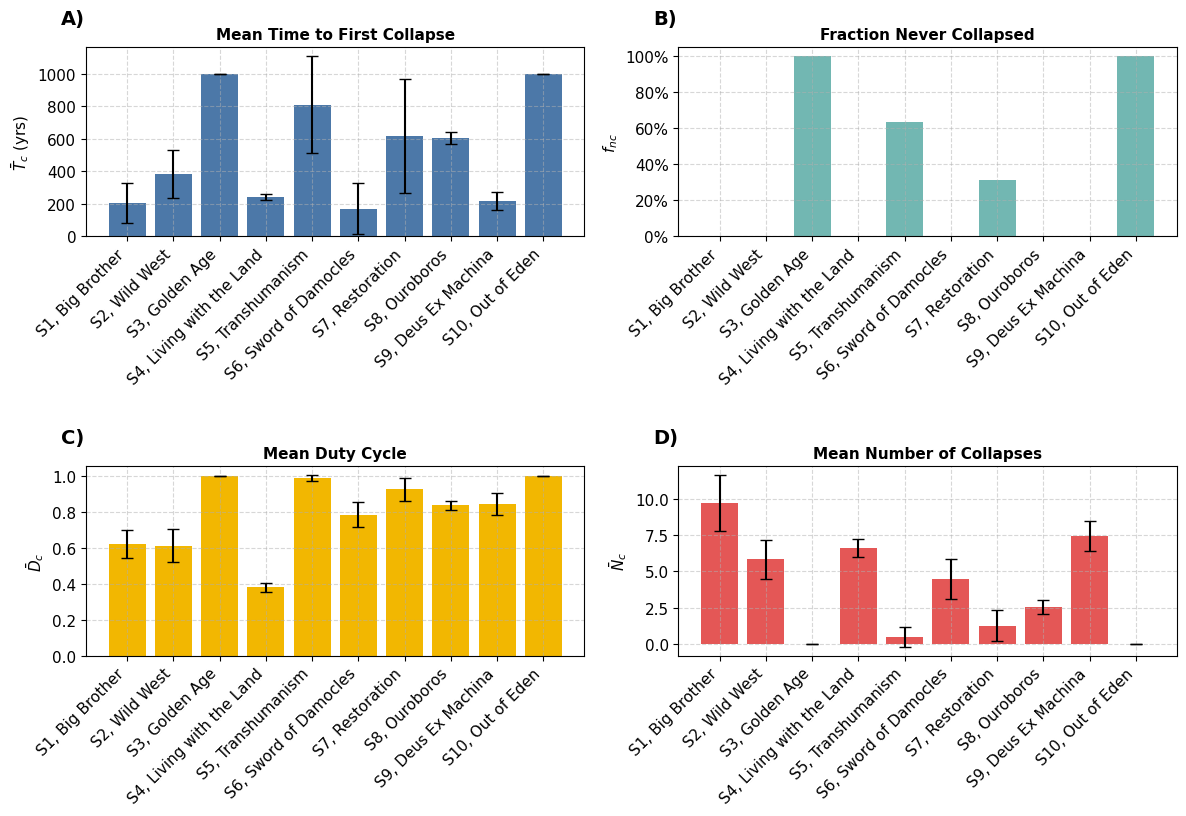

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.rcParams.update({
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.titlesize': 'medium',
    'axes.titleweight': 'semibold'
})

# Compact labels for x-axis
short_labels = {
    "S1": "S1, Big Brother",
    "S2": "S2, Wild West",
    "S3": "S3, Golden Age",
    "S4": "S4, Living with the Land",
    "S5": "S5, Transhumanism",
    "S6": "S6, Sword of Damocles",
    "S7": "S7, Restoration",
    "S8": "S8, Ouroboros",
    "S9": "S9, Deus Ex Machina",
    "S10": "S10, Out of Eden"
}

df = summary_df.copy()
df["Label"] = df["Scenario"].map(short_labels)

# Muted publication-ready colors
colors = [
    "#4C78A8",  # Muted blue
    "#72B7B2",  # Soft teal
    "#F2B701",  # Warm muted yellow
    "#E45756",  # Muted red
]

# Set global style for clarity and font
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'text.color': 'black',
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
    'savefig.edgecolor': 'white'
})

fig, axs = plt.subplots(2, 2, figsize=(12, 9))
axs = axs.flatten()

# Define panel labels
panel_labels = ['A)', 'B)', 'C)', 'D)']

# Style each axis
for ax, label in zip(axs, panel_labels):
    ax.set_xticklabels(df["Label"], rotation=45, ha='right')
    ax.grid(True, linestyle='--', alpha=0.5)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(0.8)
    # Add panel label
    ax.text(-0.05, 1.2, label, transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left')

# Plot 1: Mean Time to First Collapse (⟨T_c⟩ or T̄_c)
axs[0].bar(df["Label"], df["Mean_Collapse"], yerr=df["Std_Collapse"], capsize=4, color=colors[0])
axs[0].set_ylabel(r"$\bar{T}_{c}$ (yrs)")
axs[0].set_title("Mean Time to First Collapse")

# Plot 2: Fraction Never Collapsed
axs[1].bar(df["Label"], df["Never_Collapsed_Frac"], color=colors[1])
axs[1].set_ylabel(r"$f_{nc}$")
axs[1].set_title("Fraction Never Collapsed")
axs[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Plot 3: Mean Duty Cycle
axs[2].bar(df["Label"], df["Mean_Duty_Cycle"], yerr=df["Std_Duty_Cycle"], capsize=4, color=colors[2])
axs[2].set_ylabel(r"$\bar{D}_{c}$")
axs[2].set_title("Mean Duty Cycle")

# Plot 4: Mean Number of Collapses
axs[3].bar(df["Label"], df["Mean_Cycles"], yerr=df["Std_Cycles"], capsize=4, color=colors[3])
axs[3].set_ylabel(r"$\bar{N}_{c}$")
axs[3].set_title("Mean Number of Collapses")

# Style each axis
for ax in axs:
    ax.set_xticklabels(df["Label"], rotation=45, ha='right')
    ax.grid(True, linestyle='--', alpha=0.5)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(0.8)

# plt.suptitle("Key Collapse and Recovery Metrics by Scenario", fontsize=16, color='black')
plt.tight_layout(rect=[0, 0, 1, 0.95])

output_path = figures_dir / 'summary_panel.png'
plt.savefig(output_path)
output_path